# Análisis predictivo con Chi-cuadrado

Este notebook desarrolla un análisis predictivo usando la base de datos **`fig_7.3.3.csv`** ubicada en la carpeta **`7. Education/Data`**.

## Objetivos
- Cargar y limpiar los datos.
- Evaluar asociación entre variables categóricas con **Chi-cuadrado**.
- Medir tamaño de efecto con **V de Cramér**.
- Construir un modelo predictivo para clasificar `Type` (`CS` vs `All`).
- Visualizar resultados con librerías especializadas de gráficos.

In [20]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [21]:
# Localizar la carpeta Data de forma robusta
possible_data_directories = [
    Path.cwd() / "7. Education" / "Data",
    Path.cwd().parent / "7. Education" / "Data",
    Path.cwd() / "Data",
]

selected_data_directory = next((directory for directory in possible_data_directories if directory.exists()), None)
if selected_data_directory is None:
    raise FileNotFoundError("No se encontró la carpeta de datos. Verifica la ruta a '7. Education/Data'.")

dataset_file_path = selected_data_directory / "fig_7.3.3.csv"
education_dataset = pd.read_csv(dataset_file_path)

# Limpieza básica
education_dataset.columns = [column_name.strip() for column_name in education_dataset.columns]
education_dataset["% of postsecondary"] = (
    education_dataset["% of postsecondary"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .astype(float)
)

print(f"Archivo cargado: {dataset_file_path}")
print(f"Dimensiones: {education_dataset.shape}")
display(education_dataset.head(10))

Archivo cargado: c:\Users\nanab\Downloads\OneDrive_1_2-9-2026\7. Education\Data\fig_7.3.3.csv
Dimensiones: (64, 4)


,Degree,Type,Race/ethinicity,% of postsecondary
0,Associate,All,American Indian/Alaskan Native,1.0
1,Associate,CS,American Indian/Alaskan Native,1.0
2,Bachelor’s,All,American Indian/Alaskan Native,0.0
3,Bachelor’s,CS,American Indian/Alaskan Native,0.0
4,Master’s,All,American Indian/Alaskan Native,0.0
5,Master’s,CS,American Indian/Alaskan Native,0.0
6,PhD,All,American Indian/Alaskan Native,0.0
7,PhD,CS,American Indian/Alaskan Native,0.0
8,Associate,All,Black,12.0
9,Associate,CS,Black,12.0


In [22]:
# Exploración inicial
print("Valores únicos por variable categórica:")
for categorical_column in ["Degree", "Type", "Race/ethinicity"]:
    unique_values = sorted(education_dataset[categorical_column].unique())
    print(f"- {categorical_column}: {education_dataset[categorical_column].nunique()} -> {unique_values}")

print("\nNulos por columna:")
print(education_dataset.isna().sum())

display(
    education_dataset.groupby(["Degree", "Type"], as_index=False)["% of postsecondary"].sum().head(20)
)

Valores únicos por variable categórica:
- Degree: 4 -> ['Associate', 'Bachelor’s', 'Master’s', 'PhD']
- Type: 2 -> ['All', 'CS']
- Race/ethinicity: 8 -> ['American Indian/Alaskan Native', 'Asian', 'Black', 'Hispanic', 'NHPI', 'Two or more', 'Unknown', 'White']

Nulos por columna:
Degree                0
Type                  0
Race/ethinicity       0
% of postsecondary    0
dtype: int64


,Degree,Type,% of postsecondary
0,Associate,All,101.0
1,Associate,CS,100.0
2,Bachelor’s,All,100.0
3,Bachelor’s,CS,99.0
4,Master’s,All,99.0
5,Master’s,CS,99.0
6,PhD,All,99.0
7,PhD,CS,98.0


In [23]:
# Función para V de Cramér
def cramers_v(contingency_table: pd.DataFrame) -> float:
    chi2_statistic, _, _, _ = chi2_contingency(contingency_table)
    total_observations = contingency_table.to_numpy().sum()
    number_rows, number_columns = contingency_table.shape
    if total_observations == 0:
        return np.nan
    return np.sqrt((chi2_statistic / total_observations) / max(min(number_columns - 1, number_rows - 1), 1))


def clean_contingency_table(contingency_table: pd.DataFrame) -> pd.DataFrame:
    contingency_table = contingency_table.loc[
        contingency_table.sum(axis=1) > 0,
        contingency_table.sum(axis=0) > 0,
    ]
    if contingency_table.shape[0] < 2 or contingency_table.shape[1] < 2:
        raise ValueError("La tabla de contingencia no tiene dimensión suficiente para chi-cuadrado.")
    return contingency_table

# 1) Asociación Type vs Race/ethinicity (global)
contingency_type_by_ethnicity = pd.crosstab(
    education_dataset["Race/ethinicity"],
    education_dataset["Type"],
    values=education_dataset["% of postsecondary"],
    aggfunc="sum",
).fillna(0)
contingency_type_by_ethnicity = clean_contingency_table(contingency_type_by_ethnicity)

chi2_stat_type_ethnicity, p_value_type_ethnicity, dof_type_ethnicity, expected_frequencies_type_ethnicity = chi2_contingency(
    contingency_type_by_ethnicity
)
cramers_v_type_ethnicity = cramers_v(contingency_type_by_ethnicity)

print("Chi-cuadrado Type vs Race/ethinicity")
print(
    f"Chi2 = {chi2_stat_type_ethnicity:.4f}, "
    f"p-valor = {p_value_type_ethnicity:.6f}, "
    f"dof = {dof_type_ethnicity}, "
    f"V de Cramér = {cramers_v_type_ethnicity:.4f}"
)
display(contingency_type_by_ethnicity)

# 2) Asociación Type vs Degree (global)
contingency_type_by_degree = pd.crosstab(
    education_dataset["Degree"],
    education_dataset["Type"],
    values=education_dataset["% of postsecondary"],
    aggfunc="sum",
).fillna(0)
contingency_type_by_degree = clean_contingency_table(contingency_type_by_degree)

chi2_stat_type_degree, p_value_type_degree, dof_type_degree, _ = chi2_contingency(contingency_type_by_degree)
cramers_v_type_degree = cramers_v(contingency_type_by_degree)

print("\nChi-cuadrado Type vs Degree")
print(
    f"Chi2 = {chi2_stat_type_degree:.4f}, "
    f"p-valor = {p_value_type_degree:.6f}, "
    f"dof = {dof_type_degree}, "
    f"V de Cramér = {cramers_v_type_degree:.4f}"
)
display(contingency_type_by_degree)

Chi-cuadrado Type vs Race/ethinicity
Chi2 = 33.5106, p-valor = 0.000008, dof = 6, V de Cramér = 0.2053


Type,All,CS
Race/ethinicity,,
American Indian/Alaskan Native,1.0,1.0
Asian,35.0,81.0
Black,44.0,35.0
Hispanic,68.0,45.0
Two or more,14.0,14.0
Unknown,19.0,38.0
White,218.0,182.0



Chi-cuadrado Type vs Degree
Chi2 = 0.0038, p-valor = 0.999939, dof = 3, V de Cramér = 0.0022


Type,All,CS
Degree,,
Associate,101.0,100.0
Bachelor’s,100.0,99.0
Master’s,99.0,99.0
PhD,99.0,98.0


,Degree,chi2,p_value,dof,cramers_v
2,Master’s,18.080969,0.002847,5,0.302189
1,Bachelor’s,8.629259,0.124797,5,0.208238
3,PhD,8.142459,0.148557,5,0.203303
0,Associate,4.115528,0.661046,6,0.143092


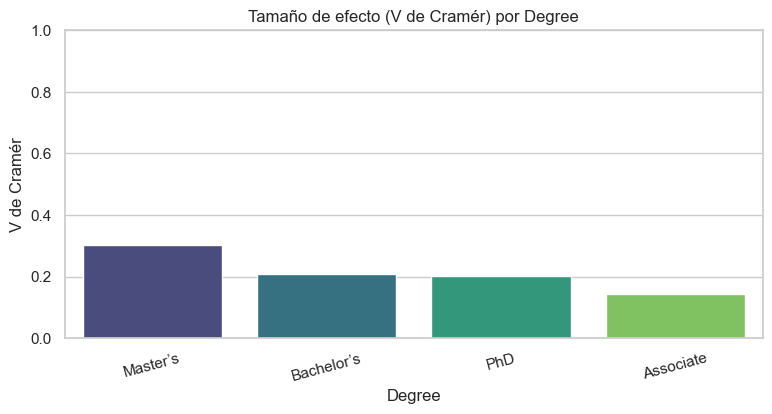

Interpretación: El nivel Master’s muestra la mayor asociación entre tipo (All/CS) y raza/etnicidad. Associate presenta la asociación más débil.


In [24]:
# Chi-cuadrado por nivel de Degree: Type vs Race/ethinicity
chi_square_results_by_degree = []
for degree_level, degree_subset in education_dataset.groupby("Degree"):
    contingency_by_degree = pd.crosstab(
        degree_subset["Race/ethinicity"],
        degree_subset["Type"],
        values=degree_subset["% of postsecondary"],
        aggfunc="sum",
    ).fillna(0)

    contingency_by_degree = contingency_by_degree.loc[
        contingency_by_degree.sum(axis=1) > 0,
        contingency_by_degree.sum(axis=0) > 0,
    ]
    if contingency_by_degree.shape[0] < 2 or contingency_by_degree.shape[1] < 2:
        continue

    chi2_statistic, p_value, degrees_of_freedom, _ = chi2_contingency(contingency_by_degree)
    chi_square_results_by_degree.append(
        {
            "Degree": degree_level,
            "chi2": chi2_statistic,
            "p_value": p_value,
            "dof": degrees_of_freedom,
            "cramers_v": cramers_v(contingency_by_degree),
        }
    )

chi_square_results_by_degree_df = pd.DataFrame(chi_square_results_by_degree).sort_values("p_value")
display(chi_square_results_by_degree_df)

plt.figure(figsize=(9, 4))
sns.barplot(data=chi_square_results_by_degree_df, x="Degree", y="cramers_v", palette="viridis")
plt.title("Tamaño de efecto (V de Cramér) por Degree")
plt.ylabel("V de Cramér")
plt.xlabel("Degree")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

print(
    "Interpretación: El nivel Master’s muestra la mayor asociación entre tipo (All/CS) y raza/etnicidad. "
    "Associate presenta la asociación más débil."
)

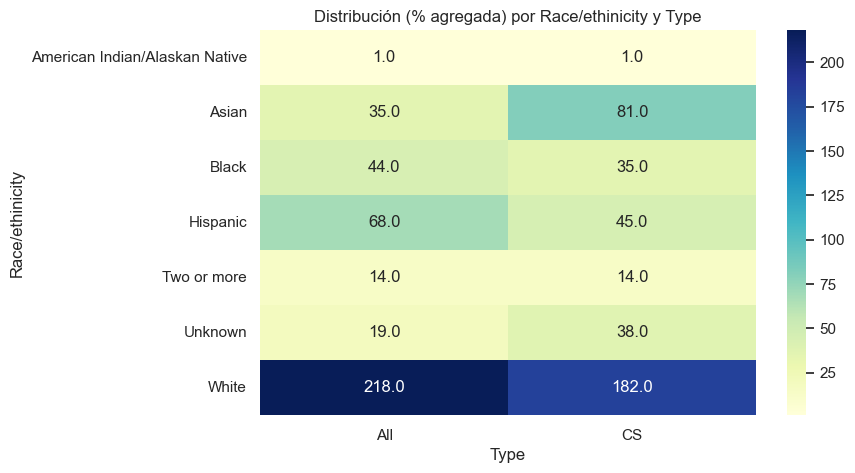

Interpretación: La categoría White concentra los valores más altos en ambos grupos, mientras Asian y Unknown muestran diferencias visibles entre All y CS.


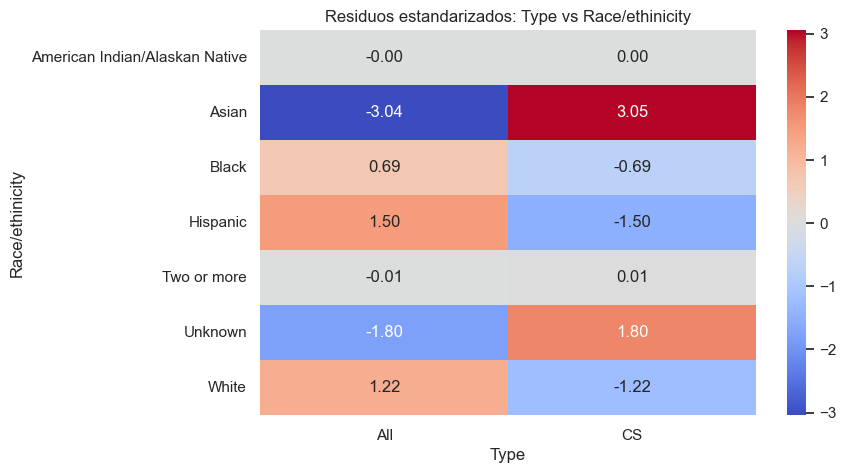

Interpretación: Valores positivos indican sobrerrepresentación respecto a lo esperado y negativos subrepresentación. Asian en CS y Unknown en CS destacan como aportes importantes al chi-cuadrado.


In [25]:
# Visualización 1: Heatmap (Type vs Race/ethinicity)
plt.figure(figsize=(8, 5))
sns.heatmap(contingency_type_by_ethnicity, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Distribución (% agregada) por Race/ethinicity y Type")
plt.xlabel("Type")
plt.ylabel("Race/ethinicity")
plt.show()

print(
    "Interpretación: La categoría White concentra los valores más altos en ambos grupos, "
    "mientras Asian y Unknown muestran diferencias visibles entre All y CS."
)

# Visualización 2: Residuos estandarizados (observado - esperado) / sqrt(esperado)
standardized_residuals_type_ethnicity = (
    contingency_type_by_ethnicity - expected_frequencies_type_ethnicity
) / np.sqrt(expected_frequencies_type_ethnicity)

plt.figure(figsize=(8, 5))
sns.heatmap(standardized_residuals_type_ethnicity, annot=True, fmt=".2f", center=0, cmap="coolwarm")
plt.title("Residuos estandarizados: Type vs Race/ethinicity")
plt.xlabel("Type")
plt.ylabel("Race/ethinicity")
plt.show()

print(
    "Interpretación: Valores positivos indican sobrerrepresentación respecto a lo esperado y negativos subrepresentación. "
    "Asian en CS y Unknown en CS destacan como aportes importantes al chi-cuadrado."
)

In [26]:
# Visualización interactiva con Plotly
interactive_distribution_figure = px.bar(
    education_dataset,
    x="Race/ethinicity",
    y="% of postsecondary",
    color="Type",
    barmode="group",
    facet_col="Degree",
    facet_col_wrap=2,
    title="Comparación por raza/etnia entre Type=All y Type=CS por Degree",
)
interactive_distribution_figure.update_layout(height=700)
interactive_distribution_figure.show()

print(
    "Interpretación: La brecha entre All y CS cambia según el nivel de Degree; "
    "las diferencias más marcadas aparecen en los grupos Asian, Hispanic y Unknown."
)

Interpretación: La brecha entre All y CS cambia según el nivel de Degree; las diferencias más marcadas aparecen en los grupos Asian, Hispanic y Unknown.


In [27]:
# -----------------------------
# Modelo predictivo (Type: CS vs All)
# -----------------------------

# Convertir tabla agregada a un dataset expandido (pseudo-observaciones)
expansion_factor = 20  # controla el tamaño del dataset sintético
expanded_observations = []

for _, dataset_row in education_dataset.iterrows():
    estimated_count = int(round(dataset_row["% of postsecondary"] * expansion_factor))
    if estimated_count <= 0:
        continue
    expanded_observations.extend(
        [
            {
                "Degree": dataset_row["Degree"],
                "Race": dataset_row["Race/ethinicity"],
                "Type": dataset_row["Type"],
            }
            for _ in range(estimated_count)
        ]
    )

expanded_training_dataset = pd.DataFrame(expanded_observations)
expanded_training_dataset["target_class"] = (expanded_training_dataset["Type"] == "CS").astype(int)

print(f"Filas del dataset expandido: {len(expanded_training_dataset):,}")
display(expanded_training_dataset.head())

predictor_features = expanded_training_dataset[["Degree", "Race"]]
target_class = expanded_training_dataset["target_class"]

features_train, features_test, target_train, target_test = train_test_split(
    predictor_features,
    target_class,
    test_size=0.25,
    random_state=42,
    stratify=target_class,
)

categorical_predictors = ["Degree", "Race"]

preprocessing_transformer = ColumnTransformer(
    transformers=[
        (
            "categorical_encoder",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_predictors,
        )
    ]
)

classification_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessing_transformer),
        ("chi2_feature_selector", SelectKBest(score_func=chi2, k="all")),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
    ]
)

classification_pipeline.fit(features_train, target_train)
predicted_classes = classification_pipeline.predict(features_test)
predicted_probabilities = classification_pipeline.predict_proba(features_test)[:, 1]

model_performance_metrics = {
    "accuracy": accuracy_score(target_test, predicted_classes),
    "precision": precision_score(target_test, predicted_classes),
    "recall": recall_score(target_test, predicted_classes),
    "f1": f1_score(target_test, predicted_classes),
    "roc_auc": roc_auc_score(target_test, predicted_probabilities),
}

print("Métricas del modelo:")
for metric_name, metric_value in model_performance_metrics.items():
    print(f"- {metric_name}: {metric_value:.4f}")

print("\nReporte de clasificación:")
print(classification_report(target_test, predicted_classes, target_names=["All", "CS"]))

Filas del dataset expandido: 15,900


,Degree,Race,Type,target_class
0,Associate,American Indian/Alaskan Native,All,0
1,Associate,American Indian/Alaskan Native,All,0
2,Associate,American Indian/Alaskan Native,All,0
3,Associate,American Indian/Alaskan Native,All,0
4,Associate,American Indian/Alaskan Native,All,0


Métricas del modelo:
- accuracy: 0.5771
- precision: 0.6606
- recall: 0.3106
- f1: 0.4225
- roc_auc: 0.5891

Reporte de clasificación:
              precision    recall  f1-score   support

         All       0.55      0.84      0.67      1995
          CS       0.66      0.31      0.42      1980

    accuracy                           0.58      3975
   macro avg       0.61      0.58      0.54      3975
weighted avg       0.61      0.58      0.54      3975



,feature,chi2_score
5,Race_Asian,306.450370
9,Race_Unknown,94.335733
7,Race_Hispanic,79.208504
10,Race_White,39.753221
6,Race_Black,20.178748
4,Race_American Indian/Alaskan Native,1.170755
2,Degree_Master’s,0.464165
0,Degree_Associate,0.333957
8,Race_Two or more,0.125310
1,Degree_Bachelor’s,0.011390


Interpretación: Las categorías de Race explican más variación que Degree; en particular Asian y Unknown tienen mayor poder discriminante para clasificar CS vs All.


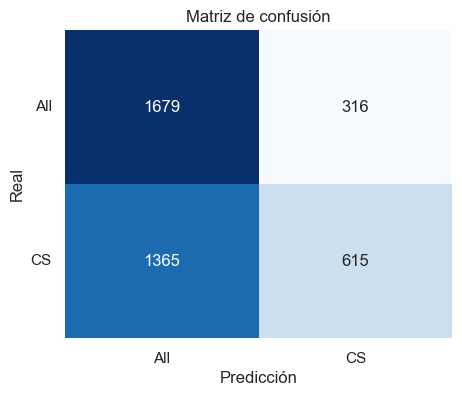

Interpretación: El modelo identifica mejor la clase All que la clase CS (más falsos negativos en CS), por lo que conviene mejorar el recall si el foco es detectar CS.


In [28]:
# Importancia de variables según chi-cuadrado (SelectKBest)
trained_encoder = classification_pipeline.named_steps["preprocess"].named_transformers_["categorical_encoder"]
encoded_feature_names = trained_encoder.get_feature_names_out(categorical_predictors)
chi2_feature_scores = classification_pipeline.named_steps["chi2_feature_selector"].scores_

feature_importance_table = pd.DataFrame(
    {
        "feature": encoded_feature_names,
        "chi2_score": chi2_feature_scores,
    }
).sort_values("chi2_score", ascending=False)

display(feature_importance_table.head(15))

feature_importance_figure = px.bar(
    feature_importance_table.head(15),
    x="chi2_score",
    y="feature",
    orientation="h",
    title="Top 15 variables más asociadas al objetivo (Chi-cuadrado)",
)
feature_importance_figure.update_layout(yaxis=dict(categoryorder="total ascending"))
feature_importance_figure.show()

print(
    "Interpretación: Las categorías de Race explican más variación que Degree; "
    "en particular Asian y Unknown tienen mayor poder discriminante para clasificar CS vs All."
)

# Matriz de confusión
confusion_matrix_values = confusion_matrix(target_test, predicted_classes)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix_values, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0.5, 1.5], ["All", "CS"])
plt.yticks([0.5, 1.5], ["All", "CS"], rotation=0)
plt.show()

print(
    "Interpretación: El modelo identifica mejor la clase All que la clase CS (más falsos negativos en CS), "
    "por lo que conviene mejorar el recall si el foco es detectar CS."
)

## Conclusiones

- La prueba de **Chi-cuadrado** permite evaluar si existe dependencia entre `Type` y variables categóricas como `Race/ethinicity` y `Degree`.
- El **V de Cramér** ayuda a interpretar el tamaño del efecto más allá del p-valor.
- El modelo predictivo usa variables categóricas codificadas y selección de variables por **Chi-cuadrado**, entregando métricas de clasificación para `CS` vs `All`.
- Las visualizaciones (Seaborn + Matplotlib + Plotly) muestran tanto patrones globales como detalles por nivel académico.

> Nota metodológica: este análisis predictivo utiliza una expansión de frecuencias (pseudo-observaciones) a partir de porcentajes agregados.

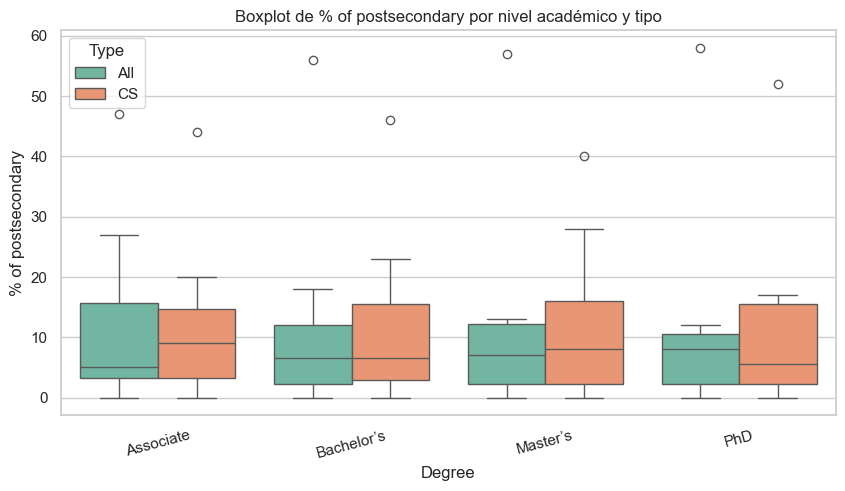

Interpretación: Las medianas de All y CS son cercanas dentro de cada Degree, pero la dispersión por raza/etnicidad genera variabilidad interna. En algunos niveles se observa mayor amplitud en CS, lo que sugiere composición desigual entre subgrupos.


In [29]:
# Boxplot: distribución de % of postsecondary por Degree y Type
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=education_dataset,
    x="Degree",
    y="% of postsecondary",
    hue="Type",
    palette="Set2"
)
plt.title("Boxplot de % of postsecondary por nivel académico y tipo")
plt.xlabel("Degree")
plt.ylabel("% of postsecondary")
plt.xticks(rotation=15)
plt.legend(title="Type")
plt.show()

print(
    "Interpretación: Las medianas de All y CS son cercanas dentro de cada Degree, "
    "pero la dispersión por raza/etnicidad genera variabilidad interna. "
    "En algunos niveles se observa mayor amplitud en CS, lo que sugiere composición desigual entre subgrupos."
)

## Conclusiones basadas en la base de datos

A partir de `fig_7.3.3.csv` (distribución porcentual por `Degree`, `Type` y `Race/ethinicity`), se obtienen las siguientes conclusiones:

- **Existe asociación estadísticamente significativa** entre `Type` (All vs CS) y `Race/ethinicity` (Chi-cuadrado con p-valor < 0.001), con tamaño de efecto bajo-moderado según V de Cramér.
- **No se observa una asociación relevante** entre `Type` y `Degree` a nivel global, ya que el p-valor es alto y V de Cramér es cercano a 0.
- En el análisis por nivel académico, **Master’s presenta la mayor intensidad de asociación** entre tipo y composición racial/étnica.
- El **boxplot** muestra que las medianas por `Degree` son similares entre `All` y `CS`, pero con diferencias en dispersión, lo que indica heterogeneidad entre subgrupos.
- El modelo predictivo (`CS` vs `All`) logra desempeño **moderado** y evidencia que las variables de `Race/ethinicity` aportan más capacidad discriminante que `Degree`.
- En la matriz de confusión se observa mejor identificación de `All` que de `CS`, por lo que podría mejorarse el recall de `CS` con técnicas de balanceo o ajuste de umbral.

> Nota: La parte predictiva se construyó a partir de expansión de frecuencias (pseudo-observaciones) derivadas de porcentajes agregados.